In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [101]:
df=pd.read_csv('circle.csv')

In [102]:
df.head()

,Unnamed: 0,feature1,feature2,label_y
0,0,8.660254,-5.00000,0
1,1,8.717792,-4.89899,0
2,2,8.773790,-4.79798,0
3,3,8.828277,-4.69697,0
4,4,8.881281,-4.59596,0


In [103]:
df.shape

(400, 4)

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  400 non-null    int64  
 1   feature1    400 non-null    float64
 2   feature2    400 non-null    float64
 3   label_y     400 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 12.6 KB


In [105]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [106]:
df.head()

,feature1,feature2,label_y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [107]:
df['label_y'].value_counts()

label_y
0    200
1    200
Name: count, dtype: int64

In [108]:
df1= df[df['label_y']==0]
df2= df[df['label_y']==1]

In [109]:
df1.shape

(200, 3)

In [110]:
df2.shape

(200, 3)

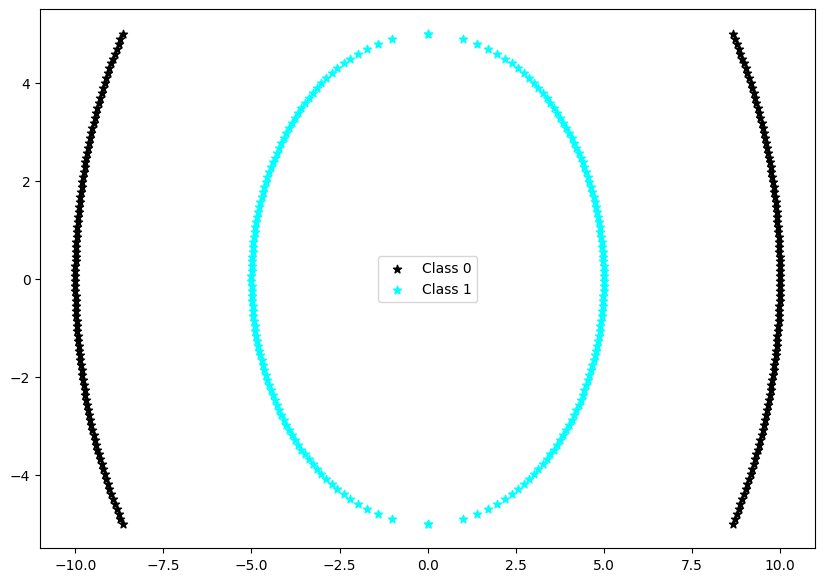

In [111]:
plt.figure(figsize=(10,7))

plt.scatter(df1['feature1'],df1['feature2'],marker='*',color='black',label='Class 0')
plt.scatter(df2['feature1'],df2['feature2'],marker='*',color='cyan',label='Class 1')

plt.legend()
plt.show()

## Train_Test_Split


In [112]:
xtrain,xtest,ytrain,ytest=train_test_split(df[['feature1','feature2']],df['label_y'],test_size=.30,random_state=42)

In [113]:
xtrain.shape

(280, 2)

In [114]:
xtrain.head()

,feature1,feature2
157,-9.971263,-0.757576
109,-9.124936,4.090909
17,9.445795,-3.282828
347,-4.993619,0.252525
24,9.662581,-2.575758


In [115]:
ytrain.head()

157    0
109    0
17     0
347    1
24     0
Name: label_y, dtype: int64

In [116]:
xtest.head()

,feature1,feature2
209,2.874798,-4.090909
280,3.938099,3.080808
33,9.860133,-1.666667
210,3.013421,-3.989899
93,8.982945,4.393939


In [117]:
ytest.head()

209    1
280    1
33     0
210    1
93     0
Name: label_y, dtype: int64

Linear

In [118]:
svm = SVC(kernel='linear')

In [119]:
svm.fit(xtrain,ytrain)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [120]:
svm.score(xtrain,ytrain)

0.5821428571428572

In [121]:
svm.score(xtest,ytest)

0.48333333333333334

Now make it from low dimensional to high dimension usingPolynomialFeatures: machine-learning preprocessing tool from scikit-learn. for 2 features

In [122]:
from sklearn.preprocessing import PolynomialFeatures

In [123]:
poly_obj=PolynomialFeatures(degree=2)

In [124]:
df.head()

,feature1,feature2,label_y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [125]:
X=df[['feature1','feature2']]
y=df['label_y']

In [126]:
X_poly=poly_obj.fit_transform(X)

In [127]:
X_poly.shape

(400, 6)

In [128]:
y.shape

(400,)

In [129]:
pd.DataFrame(y)

,label_y
0,0
1,0
2,0
3,0
4,0
...,...
395,1
396,1
397,1
398,1


Train_Test_Split

In [136]:
xtrain,xtest,ytrain,ytest=train_test_split(X_poly,y,train_size=0.70,random_state=42)

Linear Kernel

In [137]:
svm_lr=SVC(kernel='linear')

In [138]:
xtrain.shape

(280, 6)

In [139]:
ytrain.shape

(280,)

In [140]:
xtest.shape

(120, 6)

In [141]:
ytest.shape

(120,)

In [142]:
svm_lr.fit(xtrain,ytrain)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [143]:
svm_lr.score(xtrain,ytrain)

1.0

In [144]:
svm_lr.score(xtest,ytest)

1.0

Polynomial Kernel

In [145]:
poly_obj=SVC(kernel='poly')

In [146]:
poly_obj.fit(xtrain,ytrain)

,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [147]:
poly_obj.score(xtrain,ytrain)

1.0

In [148]:
poly_obj.score(xtest,ytest)

1.0

Now make it from low dimensional to high dimension Manually for 2 features

In [24]:
x1=df['feature1']
x2=df['feature2']
df['X1_Sqrt']=x1**2
df['X2_Sqrt']=x2**2
df['X1X2']= x1*x2

In [25]:
df.head()

,feature1,feature2,label_y,X1_Sqrt,X2_Sqrt,X1X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [26]:
df.shape

(400, 6)

In [27]:
X=df.drop('label_y',axis=1)
y=df['label_y']

Train_Test_Split

In [28]:
xtrain,xtest,ytrain,ytest = train_test_split(X,y,train_size=.70,random_state=42)

Linear Kernel

In [29]:
svm_lr=SVC(kernel='linear')

In [30]:
svm_lr.fit(xtrain,ytrain)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [31]:
svm_lr.score(xtrain,ytrain)

1.0

In [32]:
svm_lr.score(xtest,ytest)

1.0

In [33]:
px.scatter_3d(df,
              x='X1_Sqrt',
              y='X2_Sqrt',
              z='X1X2',
              color='label_y'
              )

Polynomial Kernel

In [34]:
svm_poly= SVC(kernel='poly')

In [35]:
svm_poly.fit(xtrain,ytrain)

,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [36]:
svm_poly.score(xtrain,ytrain)

1.0

In [37]:
svm_poly.score(xtest,ytest)

1.0

RBF Kernel

In [38]:
svm_rbf= SVC()

In [39]:
svm_rbf.fit(xtrain,ytrain)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [40]:
svm_rbf.score(xtrain,ytrain)

1.0

In [41]:
svm_rbf.score(xtest,ytest)

1.0